# Pokemon Type Classification — DL Assignment 1

**Goal:** Classify Pokemon images into 9 types using MLP → CNN → Transfer Learning.  
**Metric:** Macro-averaged F1 (chosen because of class imbalance — 2.76x ratio between majority and minority class).  
**Data:** 3600 train / 900 test, 64×64 PNG images, 9 classes.  
**Tasks:** Task 1 — MLP baseline | Task 2 — Custom CNN | Task 3 — EfficientNet Transfer Learning.

---
*Run this notebook top to bottom. Each section calls the tested `src/` Python files and displays results inline.*  
*All logic lives in `src/` — this notebook is a runner + display layer only.*

## Cell 1 — Environment Setup

Detects whether we are running locally or in Google Colab.

- **Locally:** `src/` already exists — skips clone, just installs and imports.
- **Colab (opened via GitHub UI):** clones the private repo using a GitHub Personal Access Token stored in Colab Secrets (`GITHUB_TOKEN`), installs the editable package, then prompts for Kaggle data download in the next cell.

> **One-time Colab setup:** Add your GitHub PAT to Colab Secrets: *Ferramentas → Segredos → + Adicionar segredo* → name: `GITHUB_TOKEN`, value: your token (classic, `repo` scope).


In [ ]:
import os
import subprocess
import sys

# ── Environment detection ─────────────────────────────────────────────────────
# When opened from Colab's GitHub UI, only this .ipynb is loaded — src/ is missing.
# We must clone the private repo using the Colab GitHub token.
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB and not os.path.exists("src"):
    print("Colab environment detected — cloning private repo...")

    # Colab's GitHub integration stores a token we can reuse for private repos
    from google.colab import auth
    from oauth2client.client import GoogleCredentials
    import requests

    # Get the GitHub token Colab already has from the GitHub sign-in
    try:
        from google.colab import userdata
        github_token = userdata.get("GITHUB_TOKEN")
    except Exception:
        github_token = None

    if github_token:
        clone_url = f"https://{github_token}@github.com/fmssilva/DL_Proj.git"
    else:
        # Fallback: ask user to paste token
        github_token = input("Paste your GitHub Personal Access Token (classic, repo scope): ").strip()
        clone_url = f"https://{github_token}@github.com/fmssilva/DL_Proj.git"

    subprocess.run(["git", "clone", clone_url, "DL_Proj"], check=True)
    os.chdir("DL_Proj/assignment_1")
    subprocess.run([sys.executable, "-m", "pip", "install", "-e", ".", "-q"], check=True)
    print("Repo cloned and package installed.")

    print("\n── Data setup ────────────────────────────────────────────────────────")
    print("Upload your Kaggle API key, then run the cell below to download data.")

elif not IN_COLAB:
    print("Local environment detected — src/ found, skipping clone.")
else:
    print("Colab environment detected — src/ already present, skipping clone.")

# ── Imports (safe after editable install) ────────────────────────────────────
import torch
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.config import (
    BATCH_SIZE, CLASSES, DATA_DIR, EPOCHS, IMG_SIZE_SMALL,
    LR, NUM_WORKERS, OUT_DIR, PATIENCE, SEED,
    create_output_dirs, set_seed,
)

set_seed(SEED)
create_output_dirs()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice: {device}")
print(f"PyTorch: {torch.__version__}")

CSV_PATH  = DATA_DIR / "train_labels.csv"
TRAIN_DIR = DATA_DIR / "Train"
TEST_DIR  = DATA_DIR / "Test"

df = pd.read_csv(CSV_PATH)
print(f"Loaded CSV: {len(df)} rows, {df['label'].nunique()} classes")


Local environment detected — src/ found, skipping clone.

Device: cpu
PyTorch: 2.5.1
Loaded CSV: 3600 rows, 9 classes

Device: cpu
PyTorch: 2.5.1
Loaded CSV: 3600 rows, 9 classes


In [ ]:
# ── Colab: download competition data ─────────────────────────────────────────
# Skip this cell when running locally (data/ folder already present).
# On Colab: upload your kaggle.json first, then run this cell.
#
# To get kaggle.json:
#   kaggle.com → Your profile → Settings → API → "Create New Token"

if IN_COLAB:
    data_dir = Path("data")
    if not data_dir.exists() or not any(data_dir.iterdir()):
        from google.colab import files as colab_files
        print("Upload your kaggle.json API key:")
        colab_files.upload()                                         # select kaggle.json

        import os as _os
        _os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
        subprocess.run(["cp", "kaggle.json", os.path.expanduser("~/.kaggle/")], check=True)
        subprocess.run(["chmod", "600", os.path.expanduser("~/.kaggle/kaggle.json")], check=True)

        # ↓ replace <slug> with the actual Kaggle competition or dataset slug
        KAGGLE_SLUG = "dl2425assignment1"   # ← adjust if needed
        subprocess.run(
            ["kaggle", "competitions", "download", "-c", KAGGLE_SLUG, "-p", "data/", "--unzip"],
            check=True,
        )
        print("Data downloaded to data/")
    else:
        print("data/ already present — skipping download.")
else:
    print("Local run — data/ assumed present.")


---
## Part 1 — Exploratory Data Analysis

Before training anything, we look at the data to understand:
- How many samples per class (imbalance ratio)
- Whether all images are the same size (justifies the resize choice)
- What the images actually look like per class
- Per-channel pixel statistics (justifies or challenges ImageNet normalisation)

All EDA runs on the full 3600-image training set.

In [2]:
import src.data.eda as eda

print("=== Class Distribution ===")
eda.class_distribution(df)

print("\n=== Image Size Distribution ===")
eda.image_size_distribution(TRAIN_DIR)

print("\n=== Data Integrity Check ===")
valid, invalid = eda.check_data_integrity(TRAIN_DIR, df)
print(f"Result: {valid} valid, {invalid} invalid")

=== Class Distribution ===
Class distribution:
  Water       :  674  (18.7%)
  Normal      :  606  (16.8%)
  Poison      :  467  (13.0%)
  Fire        :  381  (10.6%)
  Bug         :  374  (10.4%)
  Grass       :  299  (8.3%)
  Fighting    :  291  (8.1%)
  Rock        :  264  (7.3%)
  Ground      :  244  (6.8%)
  Imbalance ratio (max/min): 2.76x

=== Image Size Distribution ===
Image sizes: all 3600 images are 64x64

=== Data Integrity Check ===
Image sizes: all 3600 images are 64x64

=== Data Integrity Check ===
Integrity check: 3600 valid, 0 invalid images in data\Train
Integrity check: 3600 valid, 0 invalid images in data\Train
All 3600 CSV entries have matching image files
Result: 3600 valid, 0 invalid
All 3600 CSV entries have matching image files
Result: 3600 valid, 0 invalid


### Plot 1 — Class Distribution

Horizontal bar chart showing the number of samples per class, sorted from most to least frequent.

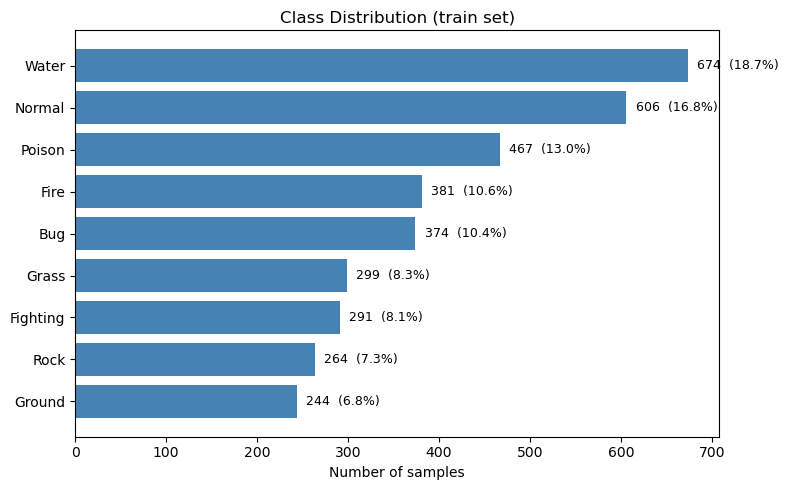

In [3]:
import src.data.eda_plots as eda_plots

fig = eda_plots.plot_class_distribution(df)
plt.show()
plt.close(fig)

> **Finding:** _TODO — fill in after running: note the imbalance ratio, which classes are majority/minority, and what this means for the loss function choice._

### Plot 2 — Sample Images per Class

4 random images per class (fixed seed — same grid on every run).

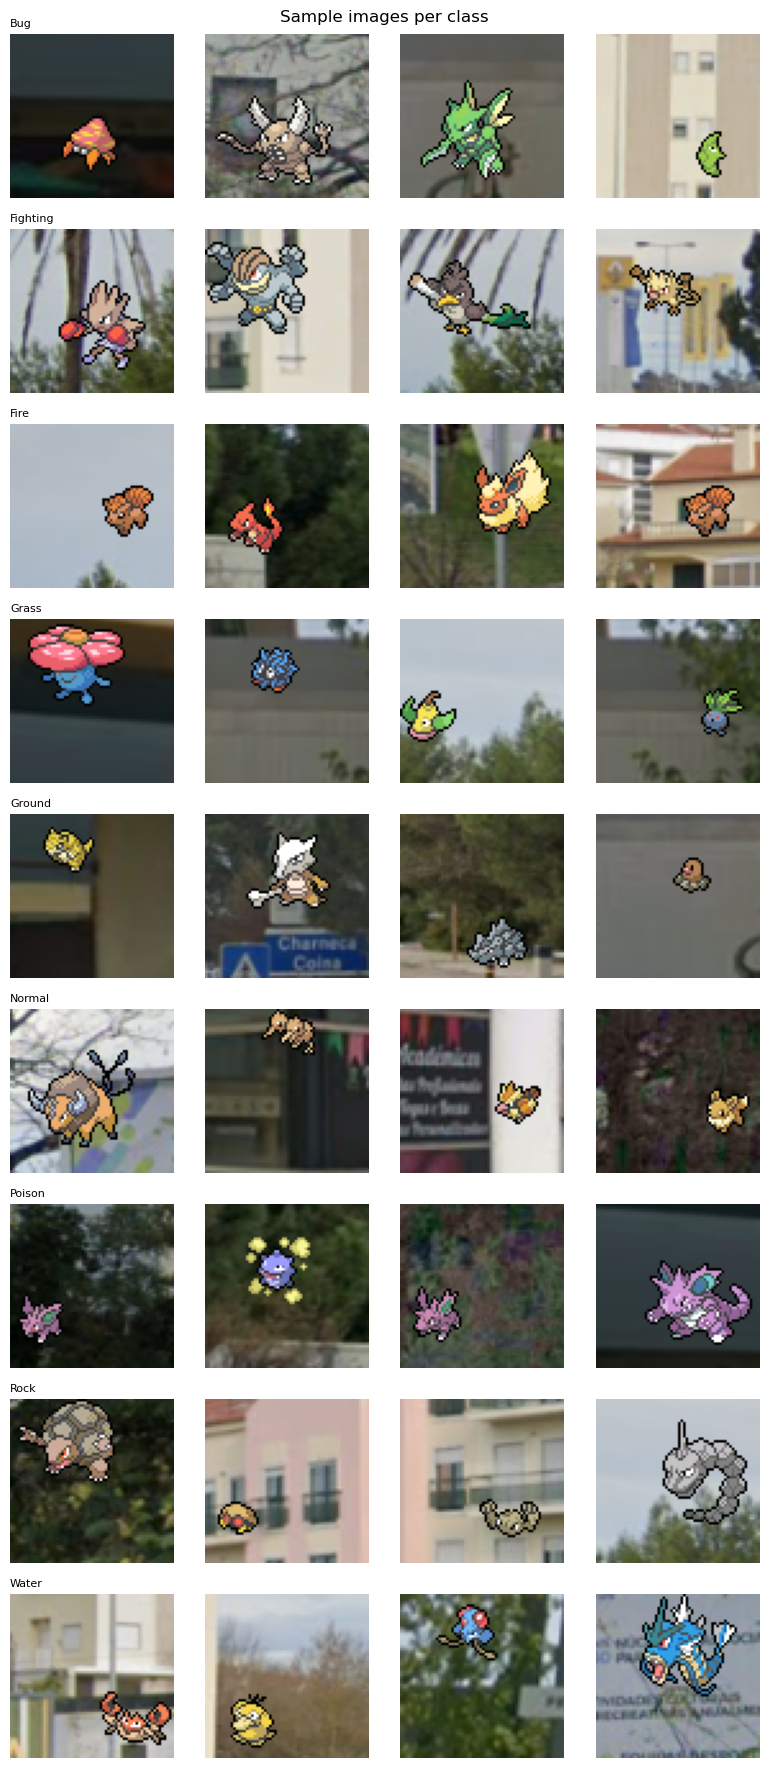

In [4]:
fig = eda_plots.plot_sample_images(TRAIN_DIR, df, n_per_class=4)
plt.show()
plt.close(fig)

> **Finding:** _TODO — note visually similar class pairs (e.g. Bug/Grass both greenish, Fighting/Normal both humanoid). These are the pairs most likely to be confused by the model._

### Plot 3 — Average Image per Class

Mean pixel value across all images in each class. A blurry mean image means high intra-class variance — the class has diverse-looking images, which makes it harder to classify.

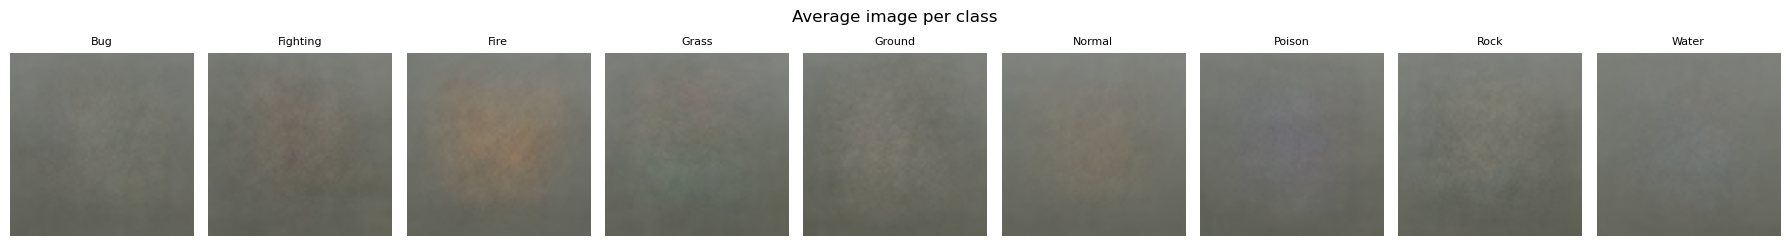

In [5]:
fig = eda_plots.plot_average_image_per_class(TRAIN_DIR, df)
plt.show()
plt.close(fig)

> **Finding:** _TODO — fill in after running_

### Plot 4 — Per-Channel Pixel Statistics

Bar chart of per-channel mean and standard deviation (R, G, B) computed across the training set.
Also prints numeric values to compare against ImageNet normalization constants.

Per-channel pixel stats (normalised 0-1):
  R: mean=0.4433, std=0.2567
  G: mean=0.4455, std=0.2464
  B: mean=0.4135, std=0.2655
ImageNet reference: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]


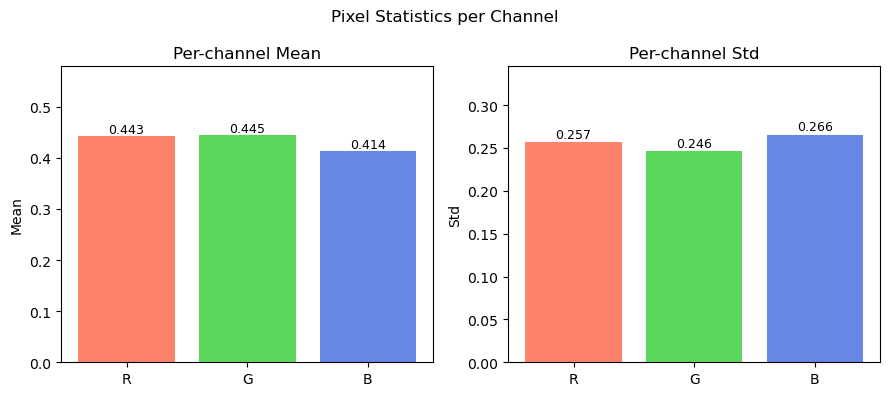

In [6]:
fig = eda_plots.plot_pixel_statistics(TRAIN_DIR, df)
plt.show()
plt.close(fig)

> **Finding:** _TODO — fill in after running_

### Plot 5 — Pixel Intensity Histogram

Histogram of pixel intensity values across R, G, B channels sampled from the training set.
Reveals the overall brightness distribution and confirms whether data is approximately normalized.

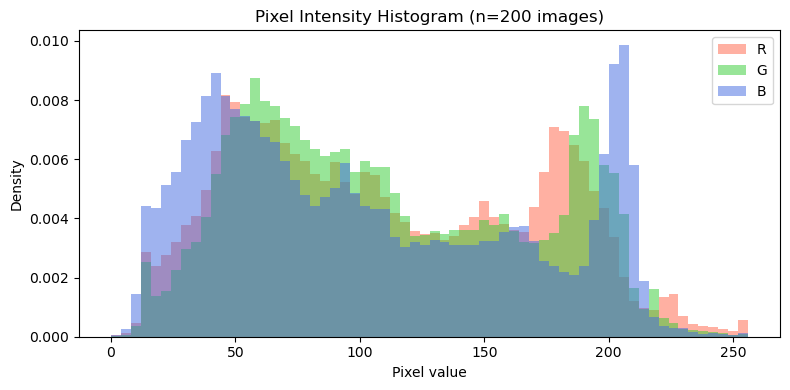

In [7]:
fig = eda_plots.plot_pixel_intensity_histogram(TRAIN_DIR, df, n_samples=200)
plt.show()
plt.close(fig)

> **Finding:** _TODO — fill in after running_

---
## Task 1 — MLP Baseline

A fully-connected Multi-Layer Perceptron treating each 64x64 RGB image as a flat vector of 12,288 features.

**Architecture:** `Flatten -> Linear(12288, 512) -> BN -> ReLU -> Dropout(0.4) -> Linear(512, 256) -> BN -> ReLU -> Dropout(0.4) -> Linear(256, 128) -> BN -> ReLU -> Dropout(0.4) -> Linear(128, 9)`

Total parameters: ~6.4M.

**Training strategy:**
- Loss: CrossEntropyLoss with class weights (handles 2.76x class imbalance)
- Optimizer: Adam (lr=1e-3)
- LR scheduler: StepLR (step_size=5, gamma=0.5)
- Early stopping: patience=5 on validation loss, saves best checkpoint

**Before running:** check `src/config.py`.
- `FAST_RUN = True` — 4 epochs, patience 2. Use this to verify the pipeline runs end-to-end (~2 min on CPU, ~1 min on GPU).
- `FAST_RUN = False` — 30 epochs, patience 5. Use this for the real training run on Colab GPU (~20 min).

In [ ]:
# check src/config.py first — FAST_RUN=True for a quick pipeline check, False for real training
# runs the full pipeline: EDA -> train -> evaluate -> save plots + submission CSV
!python task1_mlp.py

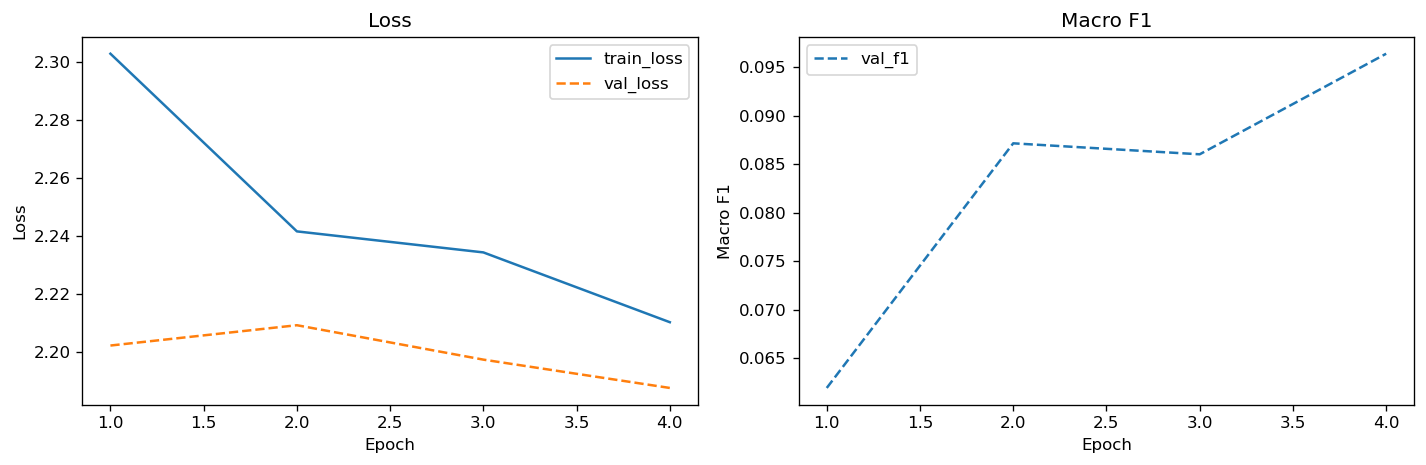

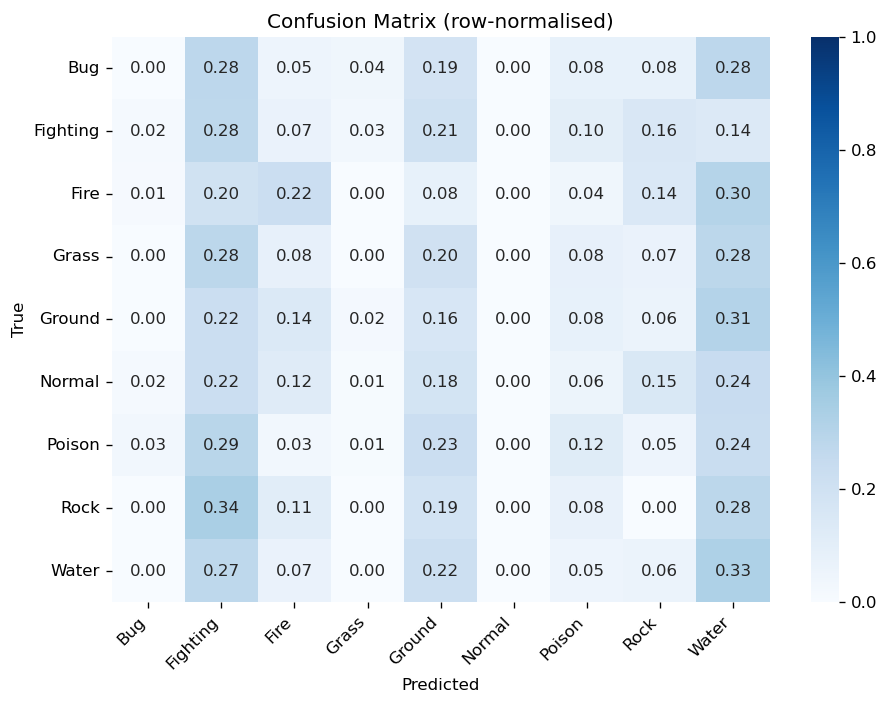

In [8]:
from IPython.display import Image, display
display(Image("outputs/plots/task1_history.png"))
display(Image("outputs/plots/task1_confusion.png"))

> **Finding:** _TODO — fill in after running_